# Library Import

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# DataFrame Creation

In [5]:
# Tabela de obras
obras = pd.DataFrame({
    "obra_id": [1, 2, 3, 4, 5],
    "nome_obra": ["Torre A", "Torre B", "Torre C", "Torre D", "Torre E"],
    "pavimentos": [5, 6, 7, 4, 8],
    "status": ["ativa"] * 5,
    "fase_inicial": ["acelerada"] * 5
})
# Timeline
datas = pd.date_range(start="2025-01-01", periods=90)

# Baseline
fator = 8 # m³ de agua por pavimento por dia
obras["consumo_base_m3"] = obras["pavimentos"] * fator

obras

,obra_id,nome_obra,pavimentos,status,fase_inicial,consumo_base_m3
0,1,Torre A,5,ativa,acelerada,40
1,2,Torre B,6,ativa,acelerada,48
2,3,Torre C,7,ativa,acelerada,56
3,4,Torre D,4,ativa,acelerada,32
4,5,Torre E,8,ativa,acelerada,64


# Water Consumption Model

In [24]:
def fator_fase(dia):
    if dia <= 30:
        return 1.2  # fase acelerada
    elif dia <= 60:
        return 1.0  # fase intermediária
    else:
        return 0.85  # fase de redução

registros = []

for _, obra in obras.iterrows():
    
    base = obra["consumo_base_m3"]
    torre = obra["nome_obra"]
    ruido_anterior = 1
    
    for i, data in enumerate(datas, start=1):
        
        fator = fator_fase(i)
        consumo_dia = base * fator

        # Noise creation
        erro = np.random.normal(0, 0.03)
        ruido = 0.6 * (ruido_anterior - 1) + erro + 1
        consumo_dia = base * fator * ruido
        
        # Leak Simulation
        if torre == 'Torre D' and i >= 35:
            fator_vazamento = 1 + 0.01 * (i - 35)
            consumo_dia *= fator_vazamento
        
    
        ruido_anterior = ruido
        
        registros.append({
            "data": data,
            "obra_id": obra["obra_id"],
            "nome_obra": obra["nome_obra"],
            "consumo_m3": consumo_dia
        })

consumo_agua = pd.DataFrame(registros)

consumo_agua.tail()

,data,obra_id,nome_obra,consumo_m3
445,2025-03-27,5,Torre E,52.215577
446,2025-03-28,5,Torre E,55.542892
447,2025-03-29,5,Torre E,56.517591
448,2025-03-30,5,Torre E,55.309941
449,2025-03-31,5,Torre E,54.989842


# Auxiliary Functions

In [37]:
def filtrar_obra(df, nome):
    if nome not in df["nome_obra"].unique():
        raise ValueError("Obra não encontrada")
    return df[df["nome_obra"] == nome].copy()

# Exploratory Data Analysis (EDA)

## DF Overview

In [48]:
consumo_agua.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   data        450 non-null    datetime64[ns]
 1   obra_id     450 non-null    int64         
 2   nome_obra   450 non-null    object        
 3   consumo_m3  450 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 14.2+ KB


In [50]:
consumo_agua.describe()

,data,obra_id,consumo_m3
count,450,450.000000,450.000000
mean,2025-02-14 11:59:59.999999744,3.000000,49.941850
min,2025-01-01 00:00:00,1.000000,31.353078
25%,2025-01-23 00:00:00,2.000000,39.994052
50%,2025-02-14 12:00:00,3.000000,47.630316
75%,2025-03-09 00:00:00,4.000000,57.864993
max,2025-03-31 00:00:00,5.000000,82.799401
std,NaN,1.415788,12.341219


## Temporal Series

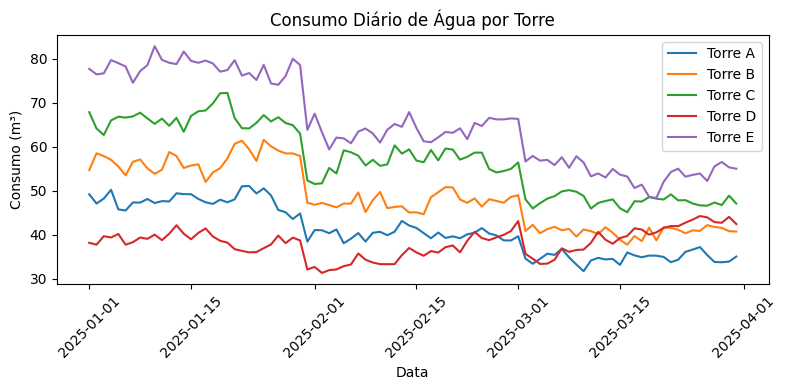

In [26]:
plt.figure(figsize=(8,4))

for nome_obra, df_obra in consumo_agua.groupby("nome_obra"):
    plt.plot(df_obra["data"], df_obra["consumo_m3"], label=nome_obra)

plt.title("Consumo Diário de Água por Torre")
plt.xlabel("Data")
plt.ylabel("Consumo (m³)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Torre D apresenta comportamento anômalo crescente após 1 etapa.

## Tower Comparison

### BoxPlot

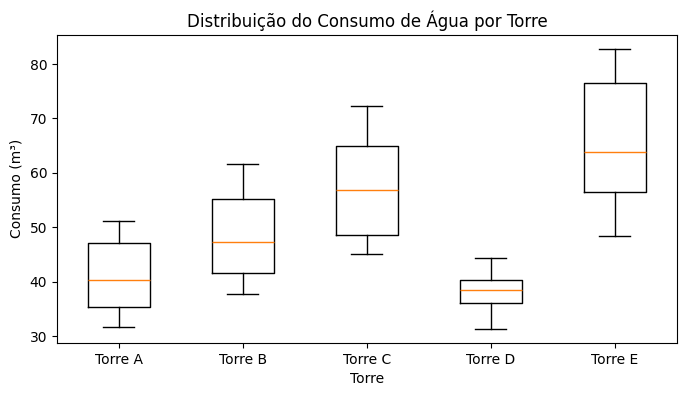

In [51]:
dados_boxplot = [
    df["consumo_m3"].values
    for _, df in consumo_agua.groupby("nome_obra")
]

labels = consumo_agua["nome_obra"].unique()

plt.figure(figsize=(8,4))
plt.boxplot(dados_boxplot, labels=labels)
plt.title("Distribuição do Consumo de Água por Torre")
plt.xlabel("Torre")
plt.ylabel("Consumo (m³)")
plt.show()

Torre D desvia do padrão crescente esperado entre torres, com menor variação no consumo.

### Average Consumption by Tower

In [44]:
media = (
    consumo_agua.groupby("nome_obra")["consumo_m3"]
    .mean()
    .sort_values()
    .to_frame("Average Consumption (m³)")
)

display(media)

,Average Consumption (m³)
nome_obra,
Torre D,38.111743
Torre A,40.920576
Torre B,48.407985
Torre C,56.907198
Torre E,65.361749


Apesar de possuir mais pavimentos que A, B e C, torre D apresenta consumo médio inferior.

### Standard Deviation by Tower

In [45]:
std = (
    consumo_agua.groupby("nome_obra")["consumo_m3"]
    .std()
    .sort_values()
    .to_frame("Standard Deviation (m³)")
)

display(std)

,Standard Deviation (m³)
nome_obra,
Torre D,3.168557
Torre A,5.569242
Torre B,6.940983
Torre C,7.915816
Torre E,10.038577


Desvio padrão torre D inferior à torre A - menor qtde. de pavimentos - implicando em consumo nas etapas 2 e 3 superiores ao esperado.

## Tower D Anomaly Evaluation

### Temporal Series

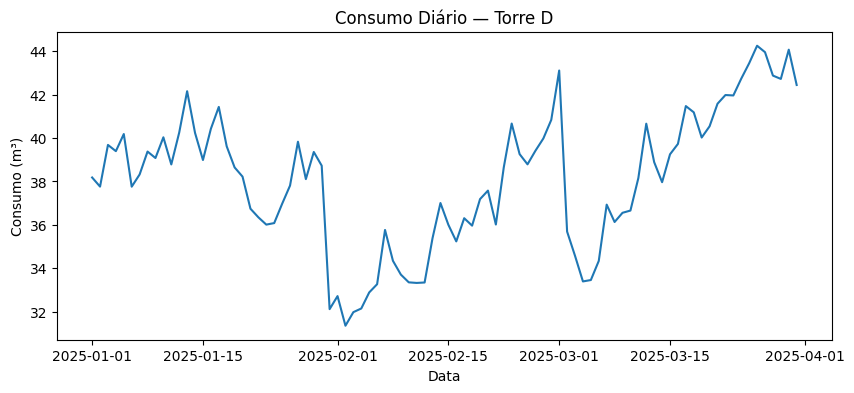

In [52]:
torre_d = filtrar_obra(consumo_agua, "Torre D")

plt.figure(figsize=(10,4))
plt.plot(torre_d["data"], torre_d["consumo_m3"])
plt.title("Consumo Diário — Torre D")
plt.xlabel("Data")
plt.ylabel("Consumo (m³)")
plt.show()

### Tower D vs Others Comparison

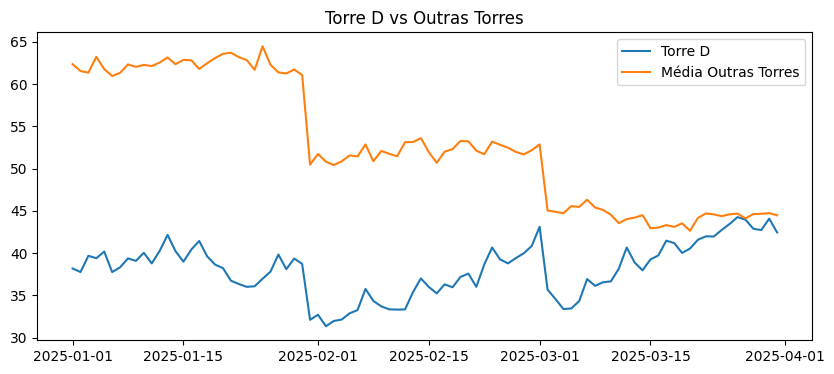

In [53]:
media_por_data = consumo_agua.groupby(["data","nome_obra"])["consumo_m3"].mean().unstack()

plt.figure(figsize=(10,4))
plt.plot(media_por_data.index, media_por_data["Torre D"], label="Torre D")

outras = media_por_data.drop(columns="Torre D").mean(axis=1)
plt.plot(media_por_data.index, outras, label="Média Outras Torres")

plt.legend()
plt.title("Torre D vs Outras Torres")
plt.show()